# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age
* Fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



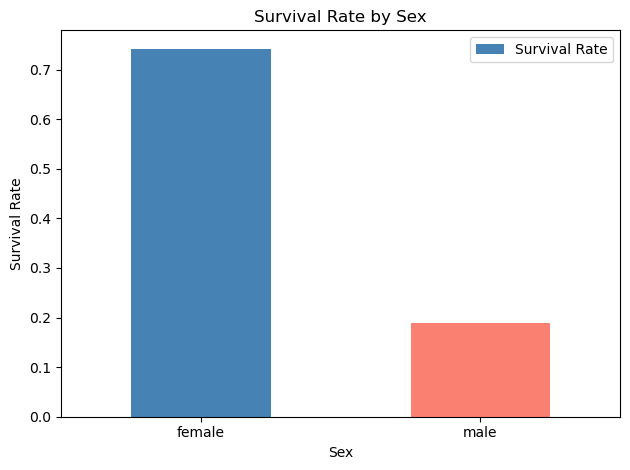

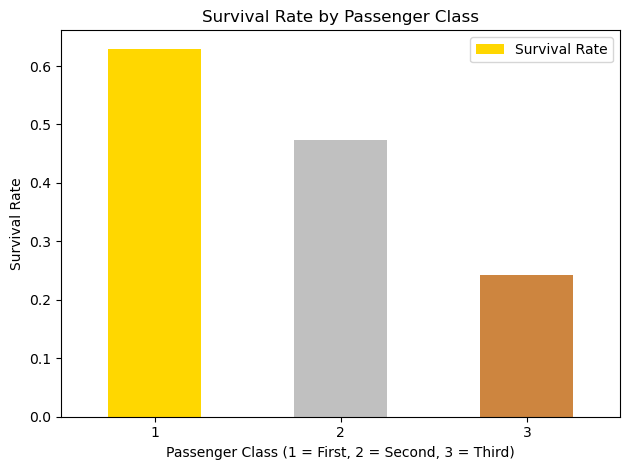

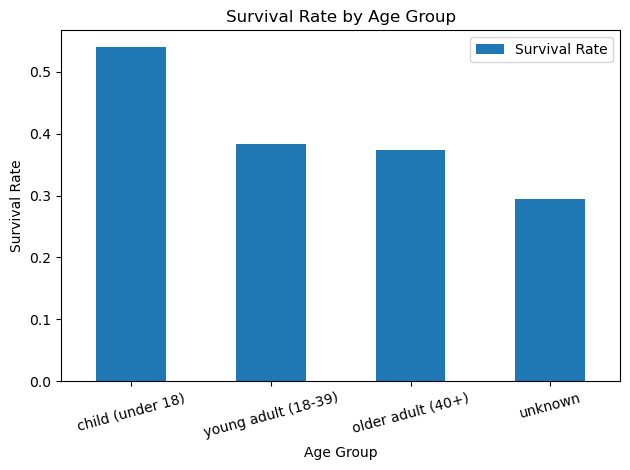

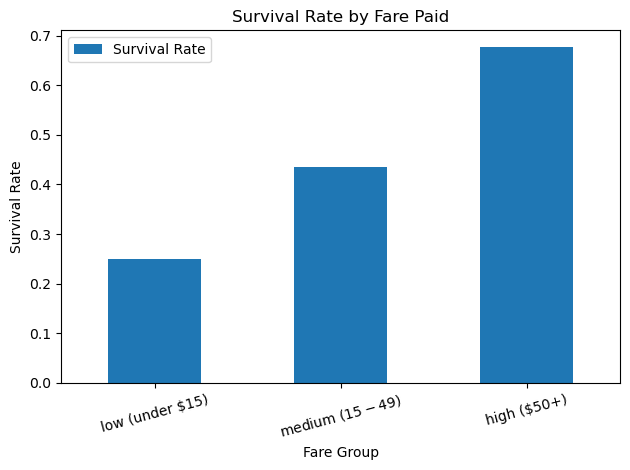

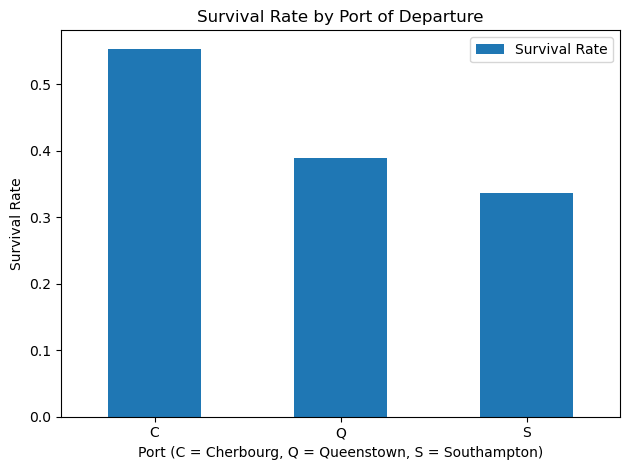

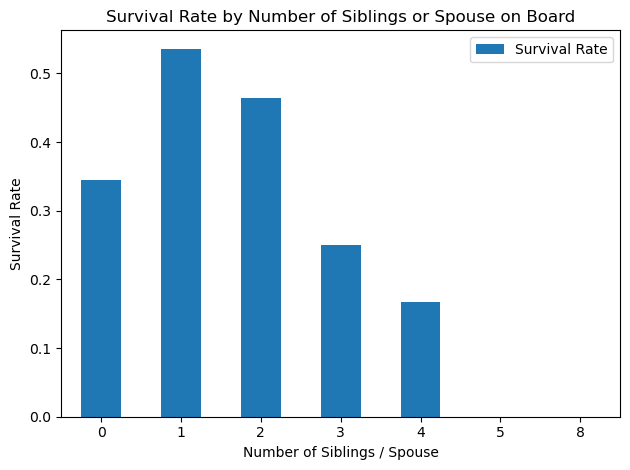

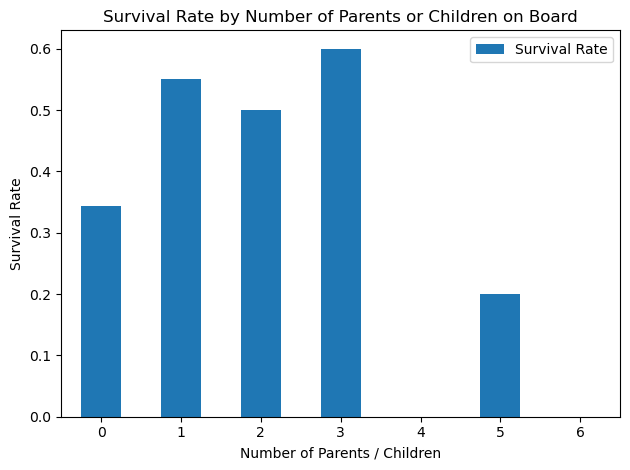

Most Likely to Survive:
                                                  Name   Age      Fare  \
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0   71.2833   
215                            Newell, Miss. Madeleine  31.0  113.2750   
218                              Bazzani, Miss. Albina  32.0   76.2917   

        Sex  Pclass  SibSp  Parch Embarked  
1    female       1      1      0        C  
215  female       1      1      0        C  
218  female       1      0      0        C  
Least Likely to Survive:
                              Name   Age  Fare   Sex  Pclass  SibSp  Parch  \
4         Allen, Mr. William Henry  35.0  8.05  male       3      0      0   
12  Saundercock, Mr. William Henry  20.0  8.05  male       3      0      0   
37        Cann, Mr. Ernest Charles  21.0  8.05  male       3      0      0   

   Embarked  
4         S  
12        S  
37        S  


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('titanic_passengers.csv')

survived = df[df['Survived'] == 1]
died = df[df['Survived'] == 0]

# Sex
df.groupby('Sex')['Survived'].mean().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.legend(['Survival Rate'])
plt.tight_layout()
plt.show()

# Passenger Class
df.groupby('Pclass')['Survived'].mean().plot(kind='bar', color=['gold', 'silver', 'peru'])
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class (1 = First, 2 = Second, 3 = Third)')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.legend(['Survival Rate'])
plt.tight_layout()
plt.show()

# Age - categorized with loc
df['age_group'] = 'unknown'
df.loc[df['Age'] < 18, 'age_group'] = 'child (under 18)'
df.loc[(df['Age'] >= 18) & (df['Age'] < 40), 'age_group'] = 'young adult (18-39)'
df.loc[df['Age'] >= 40, 'age_group'] = 'older adult (40+)'

order = ['child (under 18)', 'young adult (18-39)', 'older adult (40+)', 'unknown']
df.groupby('age_group')['Survived'].mean().reindex(order).plot(kind='bar')
plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.xticks(rotation=15)
plt.legend(['Survival Rate'])
plt.tight_layout()
plt.show()

# Fare - categorized with loc
df['fare_group'] = 'unknown'
df.loc[df['Fare'] < 15, 'fare_group'] = 'low (under $15)'
df.loc[(df['Fare'] >= 15) & (df['Fare'] < 50), 'fare_group'] = 'medium ($15-$49)'
df.loc[df['Fare'] >= 50, 'fare_group'] = 'high ($50+)'

fare_order = ['low (under $15)', 'medium ($15-$49)', 'high ($50+)']
df.groupby('fare_group')['Survived'].mean().reindex(fare_order).plot(kind='bar')
plt.title('Survival Rate by Fare Paid')
plt.xlabel('Fare Group')
plt.ylabel('Survival Rate')
plt.xticks(rotation=15)
plt.legend(['Survival Rate'])
plt.tight_layout()
plt.show()

# Port of Departure
df.groupby('Embarked')['Survived'].mean().plot(kind='bar')
plt.title('Survival Rate by Port of Departure')
plt.xlabel('Port (C = Cherbourg, Q = Queenstown, S = Southampton)')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.legend(['Survival Rate'])
plt.tight_layout()
plt.show()

# Siblings / Spouse
df.groupby('SibSp')['Survived'].mean().plot(kind='bar')
plt.title('Survival Rate by Number of Siblings or Spouse on Board')
plt.xlabel('Number of Siblings / Spouse')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.legend(['Survival Rate'])
plt.tight_layout()
plt.show()

# Parents / Children
df.groupby('Parch')['Survived'].mean().plot(kind='bar')
plt.title('Survival Rate by Number of Parents or Children on Board')
plt.xlabel('Number of Parents / Children')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.legend(['Survival Rate'])
plt.tight_layout()
plt.show()

# Most likely to survive profile match
most_likely = df[
    (df['Sex'] == 'female') &
    (df['Pclass'] == 1) &
    (df['age_group'] == 'young adult (18-39)') &
    (df['fare_group'] == 'high ($50+)') &
    (df['Embarked'] == 'C') &
    (df['SibSp'] <= 1) &
    (df['Parch'] <= 1) &
    (df['Survived'] == 1)
]
print('Most Likely to Survive:')
print(most_likely[['Name', 'Age', 'Fare', 'Sex', 'Pclass', 'SibSp', 'Parch', 'Embarked']].head(3))

# Least likely to survive profile match
least_likely = df[
    (df['Sex'] == 'male') &
    (df['Pclass'] == 3) &
    (df['age_group'] == 'young adult (18-39)') &
    (df['fare_group'] == 'low (under $15)') &
    (df['Embarked'] == 'S') &
    (df['SibSp'] == 0) &
    (df['Parch'] == 0) &
    (df['Survived'] == 0)
]
print('Least Likely to Survive:')
print(least_likely[['Name', 'Age', 'Fare', 'Sex', 'Pclass', 'SibSp', 'Parch', 'Embarked']].head(3))

In [ ]:
QUANTITATIVE FEATURE CATEGORIZATION

For age I split it into three groups, children (under 18), young adults (18-39), and older adults (40+). I chose 18 as the cutoff because kids were probably saved first since that's just what people would do. I chose 40 as the second cutoff because older people might have had a harder time physically getting to a lifeboat in time.

For fare I did low (under $15), medium ($15-$49), and high ($50+). I picked these cutoffs because they basically line up with the three classes. Third class tickets were really cheap, first class were expensive, and second class was somewhere in the middle. So the fare groups kind of tell the same story as passenger class.


MOST LIKELY TO SURVIVE — CHARACTER PROFILE

Sex: Female
Women had a survival rate of about 74% compared to only 19% for men. That's a huge difference and you can see it clearly in the bar chart. Women were definitely prioritized when it came to getting on lifeboats.

Passenger Class: First Class
First class passengers survived at about 63% which is way higher than third class at only 24%. First class was closer to the lifeboats and they probably had more time and help getting out.

Age: Young adult (18-39)
Young adult women in first class had really good odds of surviving based on the chart.

Fare: High ($50+)
Passengers who paid more had a much higher survival rate. This makes sense because higher fares = higher class = better access to lifeboats.

Port of Departure: Cherbourg
Cherbourg had the highest survival rate at around 55%. A lot of wealthy passengers boarded there which probably explains it.

Travel Companions: 1 boss
The chart shows that people with one companion actually survived more than people traveling alone or with a big family, she was a secratary.

Real Passenger Match: Miss. Laura Mabel Francatelli, age 30, first class, boarded at Cherbourg, fare $133.65, survived.

Interesting Fact:
After the titanic she married and did not settle, in Britain and in July 1916 Laura migrated to the USA aboard the Philadelphia.



LEAST LIKELY TO SURVIVE — CHARACTER PROFILE

Sex: Male
Like I mentioned above men only had a 19% survival rate. The bar chart makes it really obvious that being male was basically the biggest thing working against you.

Passenger Class: Third Class
Third class had the lowest survival rate by far at around 24%. They were stuck at the bottom of the ship and there's actually evidence that some gates were locked keeping them from getting to the lifeboats.

Age: Young adult (18-39)
Even though young men were probably physically fit enough to handle it they still didn't survive because they weren't given priority access to the lifeboats.

Fare: Low (under $15)
Low fare passengers were almost all in third class so it makes sense their survival rate was the worst.

Port of Departure: Southampton
Southampton had the lowest survival rate of the three ports at about 34%. Most third class passengers boarded there.

Travel Companions: 5 family members cousins
lost in the sinking along with his 5 relatives

Real Passenger Match: Mr. Owen Harris Braund, age 22, third class, boarded at Southampton, fare $7.25, did not survive.

Interesting Fact:
He was on the titanic after being encouraged by his older brother to emigrate to canada.